# Analyzation of Wind Speed for Masked Forecasts

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from typing import Union, Optional, List

In [41]:
def plot_mean_wind_speed_comparison(
    masked_folder: str,
    input_path: Union[str, os.PathLike],
    region_lat: slice = slice(55.0, 53.0),
    region_lon: slice = slice(7.5, 10.5),
    title: str = "Mean Wind Speed at 22:00 UTC over North Germany (10m) – Feature Occlusion",
    rename_map: Optional[dict] = None,
    order: Optional[List[str]] = None,
):
    """
    Plots a bar chart comparing 10m wind speed at 22:00 UTC over a region for masked and unmasked predictions.

    Parameters
    ----------
    masked_folder : str
        Directory containing NetCDF predictions with masked variables.
    input_path : str or Path
        Path to the unmasked input NetCDF file.
    region_lat : slice, optional
        Latitude slice for the region of interest. Default is North Germany.
    region_lon : slice, optional
        Longitude slice for the region of interest. Default is North Germany.
    title : str, optional
        Title for the plot.
    rename_map : dict, optional
        Optional mapping from original labels (filenames) to new display names.
    order : list of str, optional
        Optional custom order of bar labels (must match renamed labels if rename_map is used).
    """
    def mean_wind_speed(ds, time_sel=None):
        if time_sel is not None:
            u10 = ds["10m_u_component_of_wind"].isel(time=time_sel)
            v10 = ds["10m_v_component_of_wind"].isel(time=time_sel)
        else:
            u10 = ds["10m_u_component_of_wind"].squeeze()
            v10 = ds["10m_v_component_of_wind"].squeeze()

        wind_speed = np.sqrt(u10**2 + v10**2)
        return wind_speed.sel(lat=region_lat, lon=region_lon).mean().item()

    wind_means = {}

    # Unmasked
    unmasked_ds = xr.open_dataset(input_path)
    time_sel = int(np.where(unmasked_ds.time.dt.hour == 22)[0][0])
    wind_means["Unmasked"] = mean_wind_speed(unmasked_ds, time_sel)

    # Masked
    for fname in sorted(os.listdir(masked_folder)):
        if not fname.endswith(".nc"):
            continue
        path = os.path.join(masked_folder, fname)
        ds = xr.open_dataset(path)
        label = fname.replace("masked_", "").replace(".nc", "")
        display_label = rename_map[label] if rename_map and label in rename_map else label
        wind_means[display_label] = mean_wind_speed(ds)

    # Apply custom order if provided
    if order:
        labels = [lbl for lbl in order if lbl in wind_means]
    else:
        labels = list(wind_means.keys())

    values = [wind_means[lbl] for lbl in labels]

    # Plot
    plt.figure(figsize=(10, 6))
    plt.bar(labels, values)
    plt.ylabel("10m Wind Speed at 22:00 UTC (m/s)")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


In [16]:
input_path="../data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc"

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_36448/3766263726.py:53: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_36448/3766263726.py:53: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_36448/3766263726.py:53: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_36448/37662

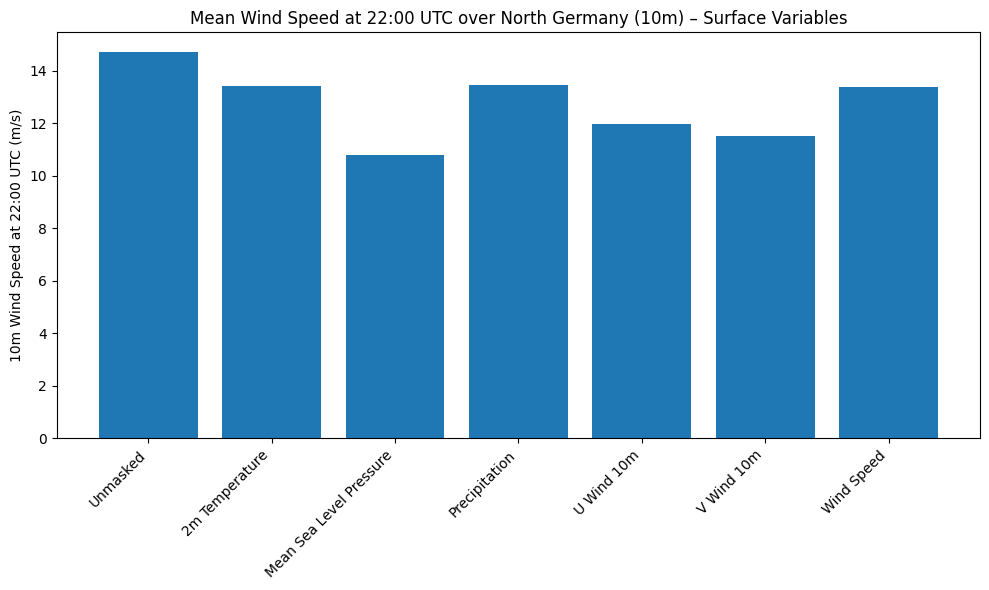

In [42]:
rename_map = {
    "2m_temperature_levnone_regnone_tnone": "2m Temperature",
    "10m_u_component_of_wind_levnone_regnone_tnone": "U Wind 10m",
    "10m_v_component_of_wind_levnone_regnone_tnone": "V Wind 10m",
    "mean_sea_level_pressure_levnone_regnone_tnone": "Mean Sea Level Pressure",
    "total_precipitation_6hr_levnone_regnone_tnone": "Precipitation",
    "('10m_u_component_of_wind', '10m_v_component_of_wind')_levnone_regnone_tnone": "Wind Speed"
}

plot_mean_wind_speed_comparison(
    masked_folder="../data/feature_occlusion/surface_variables",
    input_path=input_path,
    title = "Mean Wind Speed at 22:00 UTC over North Germany (10m) – Surface Variables",
    rename_map=rename_map,
    order=[
        "Unmasked",
        "2m Temperature",
        "Mean Sea Level Pressure",
        "Precipitation",
        "U Wind 10m",
        "V Wind 10m",
        "Wind Speed"
    ]
)

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_36448/3766263726.py:53: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_36448/3766263726.py:53: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_36448/3766263726.py:53: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_36448/37662

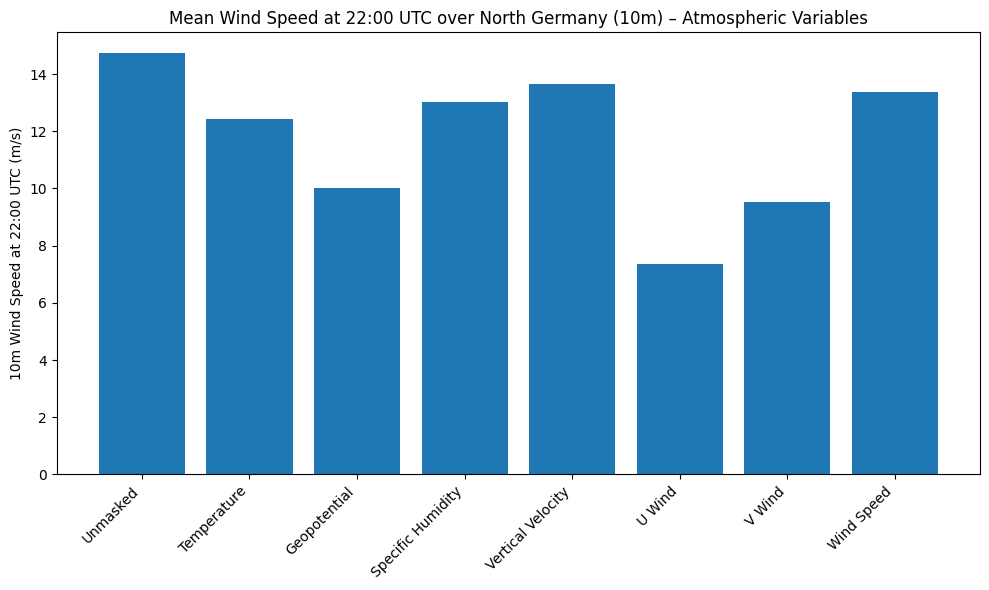

In [44]:
rename_map = {
    "temperature_levnone_regnone_tnone": "Temperature",
    "u_component_of_wind_levnone_regnone_tnone": "U Wind",
    "v_component_of_wind_levnone_regnone_tnone": "V Wind",
    "geopotential_levnone_regnone_tnone": "Geopotential",
    "vertical_velocity_levnone_regnone_tnone": "Vertical Velocity",
    "specific_humidity_levnone_regnone_tnone": "Specific Humidity",
    "('u_component_of_wind', 'v_component_of_wind')_levnone_regnone_tnone": "Wind Speed"
}

plot_mean_wind_speed_comparison(
    masked_folder="../data/feature_occlusion/atmospheric_variables",
    input_path=input_path,
    title = "Mean Wind Speed at 22:00 UTC over North Germany (10m) – Atmospheric Variables",
    rename_map=rename_map,
    order=[
        "Unmasked",
        "Temperature",
        "Geopotential",
        "Specific Humidity",
        "Vertical Velocity",
        "U Wind",
        "V Wind",
        "Wind Speed"
    ]
)

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_36448/3766263726.py:53: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_36448/3766263726.py:53: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_36448/3766263726.py:53: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_36448/37662

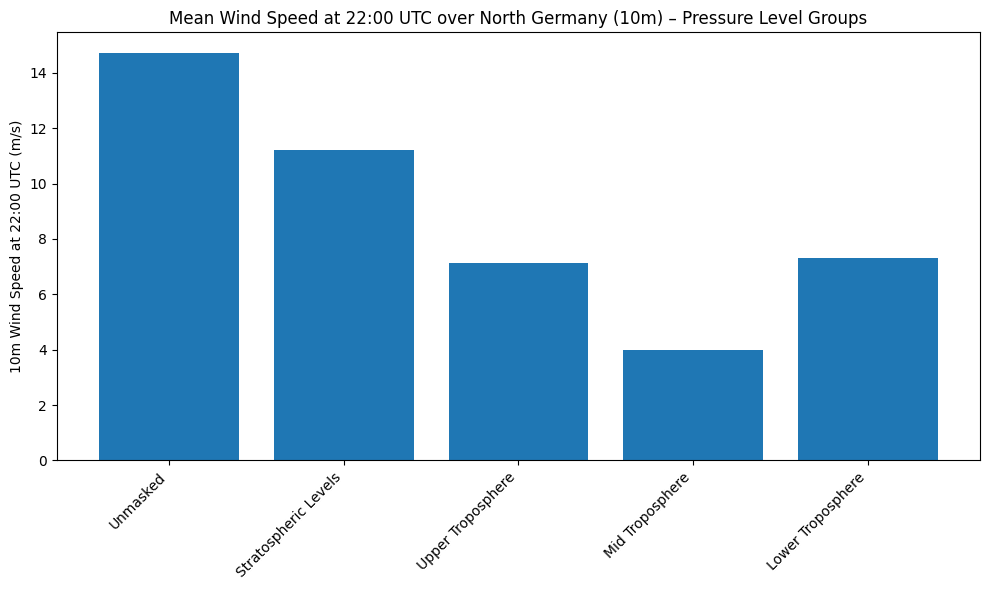

In [45]:
rename_map = {
    "none_lev(50, 100, 150, 200)_regnone_tnone": "Stratospheric Levels",
    "none_lev(250, 300, 400)_regnone_tnone": "Upper Troposphere",
    "none_lev(500, 600, 700)_regnone_tnone": "Mid Troposphere",
    "none_lev(850, 925, 1000)_regnone_tnone": "Lower Troposphere"
}

plot_mean_wind_speed_comparison(
    masked_folder="../data/feature_occlusion/pressure_level_groups",
    input_path=input_path,
    title="Mean Wind Speed at 22:00 UTC over North Germany (10m) – Pressure Level Groups",
    rename_map=rename_map,
    order=[
        "Unmasked",
        "Stratospheric Levels",
        "Upper Troposphere",
        "Mid Troposphere",
        "Lower Troposphere"
    ]
)

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_36448/3766263726.py:53: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_36448/3766263726.py:53: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_36448/3766263726.py:53: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_36448/37662

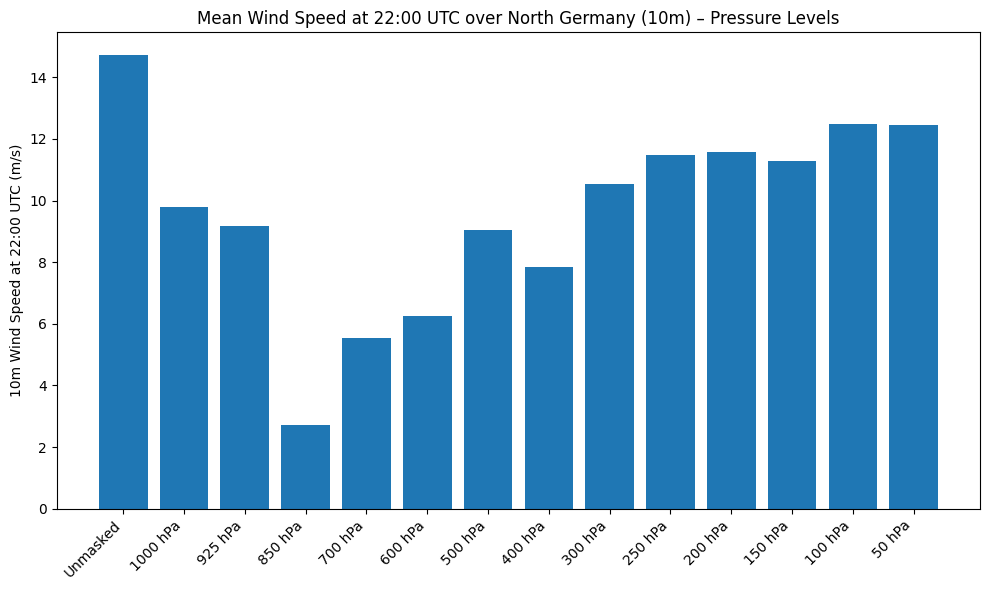

In [46]:
rename_map = {
    "none_lev1000_regnone_tnone": "1000 hPa",
    "none_lev925_regnone_tnone": "925 hPa",
    "none_lev850_regnone_tnone": "850 hPa",
    "none_lev700_regnone_tnone": "700 hPa",
    "none_lev600_regnone_tnone": "600 hPa",
    "none_lev500_regnone_tnone": "500 hPa",
    "none_lev400_regnone_tnone": "400 hPa",
    "none_lev300_regnone_tnone": "300 hPa",
    "none_lev250_regnone_tnone": "250 hPa",
    "none_lev200_regnone_tnone": "200 hPa",
    "none_lev150_regnone_tnone": "150 hPa",
    "none_lev100_regnone_tnone": "100 hPa",
    "none_lev50_regnone_tnone": "50 hPa"
}

plot_mean_wind_speed_comparison(
    masked_folder="../data/feature_occlusion/pressure_levels",
    input_path=input_path,
    title="Mean Wind Speed at 22:00 UTC over North Germany (10m) – Pressure Levels",
    rename_map=rename_map,
    order=[
        "Unmasked",
        "1000 hPa",
        "925 hPa",
        "850 hPa",
        "700 hPa",
        "600 hPa",
        "500 hPa",
        "400 hPa",
        "300 hPa",
        "250 hPa",
        "200 hPa",
        "150 hPa",
        "100 hPa",
        "50 hPa"
    ]
)

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_36448/3766263726.py:53: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_36448/3766263726.py:53: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_36448/3766263726.py:53: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_36448/37662

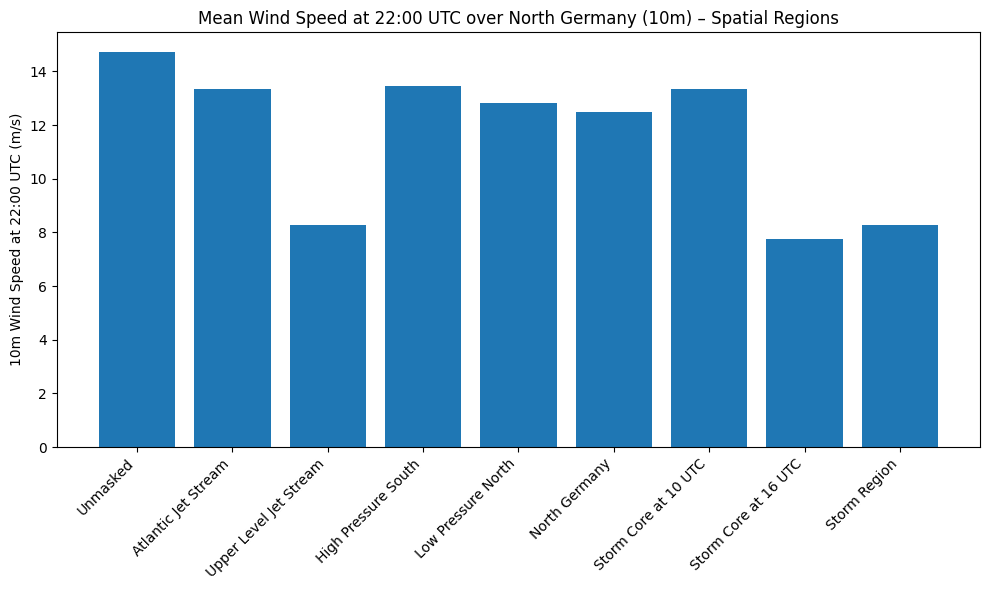

In [47]:
rename_map = {
    "none_levnone_regatlantic_jet_stream_tnone": "Atlantic Jet Stream",
    "none_levnone_regupper_level_jet_stream_tnone": "Upper Level Jet Stream",
    "none_levnone_reghigh_pressure_south_tnone": "High Pressure South",
    "none_levnone_reglow_pressure_north_tnone": "Low Pressure North",
    "none_levnone_regnorth_germany_tnone": "North Germany",
    "none_levnone_regstorm_core_10utc_tnone": "Storm Core at 10 UTC",
    "none_levnone_regstorm_core_16utc_tnone": "Storm Core at 16 UTC",
    "none_levnone_regstorm_region_tnone": "Storm Region",
}

plot_mean_wind_speed_comparison(
    masked_folder="../data/feature_occlusion/spatial_regions",
    input_path=input_path,
    title="Mean Wind Speed at 22:00 UTC over North Germany (10m) – Spatial Regions",
    rename_map=rename_map,
    order=[
        "Unmasked",
        "Atlantic Jet Stream",
        "Upper Level Jet Stream",
        "High Pressure South",
        "Low Pressure North",
        "North Germany",
        "Storm Core at 10 UTC",
        "Storm Core at 16 UTC",
        "Storm Region"
    ]
)

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_36448/64442281.py:50: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_36448/64442281.py:50: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)


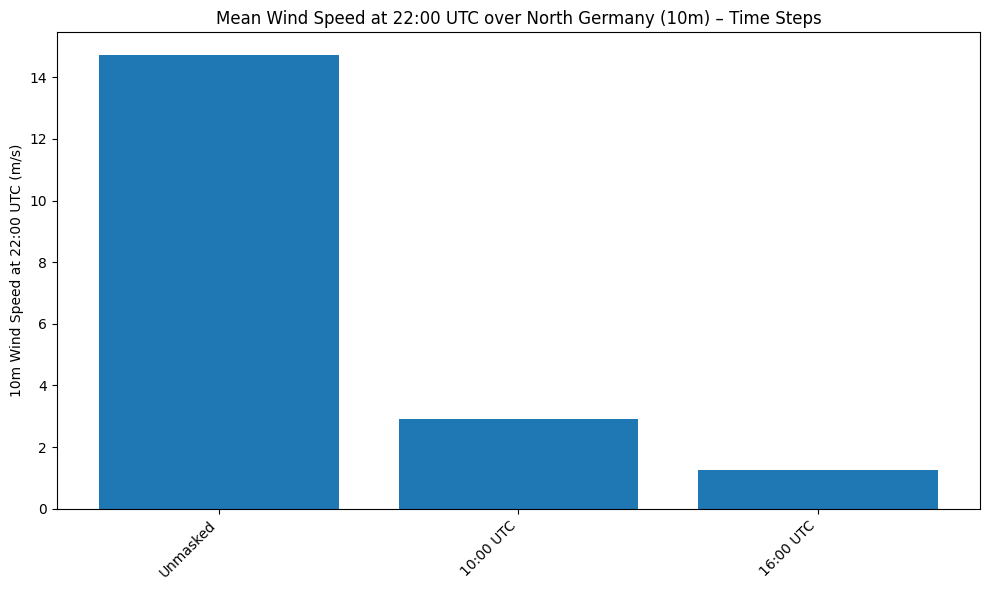

In [37]:
rename_map = {
    "none_levnone_regnone_t0": "10:00 UTC",
    "none_levnone_regnone_t1": "16:00 UTC",
}

plot_mean_wind_speed_comparison(
    masked_folder="../data/feature_occlusion/time_steps",
    input_path=input_path,
    title="Mean Wind Speed at 22:00 UTC over North Germany (10m) – Time Steps",
    rename_map=rename_map
)

## Multiple Features

In [1]:
import os
import re
import ast
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from typing import Union

In [2]:
def plot_feature_grouped_heatmap(
    masked_folder: Union[str, os.PathLike],
    input_path: Union[str, os.PathLike],
    group_x: str = "Pressure Levels",
    group_y: str = "Variable",
    region_lat: slice = slice(55.0, 53.0),
    region_lon: slice = slice(7.5, 10.5),
    title: str = "Mean 10m Wind Speed – Grouped Heatmap"
):
    """
    Plot a heatmap showing mean wind speed grouped by two features parsed from filenames.

    Parameters
    ----------
    masked_folder : str or Path
        Directory containing masked NetCDF files.
    input_path : str or Path
        Path to unmasked NetCDF input file for reference.
    group_x : str
        Column to group by on the x-axis ("Pressure Levels", "Region", etc.).
    group_y : str
        Column to group by on the y-axis ("Variable", etc.).
    region_lat : slice
        Latitude bounds of region of interest.
    region_lon : slice
        Longitude bounds of region of interest.
    title : str
        Title for the plot.
    """

    def parse_filename_general(fname):
        name = fname.replace("masked_", "").replace(".nc", "")
        groups = {}
        # Extract variable
        var_match = re.match(r"(\(.*?\)|[^_]+)_", name)
        if var_match:
            var_str = var_match.group(1)
            try:
                parsed = ast.literal_eval(var_str)
                if isinstance(parsed, tuple):
                    groups["Variable"] = "\n".join(parsed)
                else:
                    groups["Variable"] = parsed
            except Exception:
                groups["Variable"] = var_str
            name = name[var_match.end():]

        # Extract any group like lev(...), reg..., t...
        group_patterns = {
            "Pressure Levels": r"lev\((.*?)\)",
            "Region": r"reg([a-zA-Z0-9_]+)",
            "Time Step": r"t([0-9\-]+|none)"
        }

        for key, pattern in group_patterns.items():
            m = re.search(pattern, name)
            if m:
                groups[key] = m.group(1)

        return groups

    def mean_wind_speed(ds):
        u10 = ds["10m_u_component_of_wind"]
        v10 = ds["10m_v_component_of_wind"]
        wind_speed = np.sqrt(u10**2 + v10**2)
        return wind_speed.sel(lat=region_lat, lon=region_lon).squeeze().mean().item()

    # Get time selection from unmasked input
    unmasked_ds = xr.open_dataset(input_path)
    time_sel = int(np.where(unmasked_ds.time.dt.hour == 22)[0][0])

    # Collect data
    records = []
    for fname in sorted(os.listdir(masked_folder)):
        if not fname.endswith(".nc"):
            continue

        groups = parse_filename_general(fname)
        if group_x not in groups or group_y not in groups:
            continue

        ds = xr.open_dataset(os.path.join(masked_folder, fname))
        ds = ds.isel(time=0) if "time" in ds.dims and ds.dims["time"] == 1 else ds.isel(time=time_sel)
        value = mean_wind_speed(ds)
        records.append((groups[group_y], groups[group_x], value))

    if not records:
        raise ValueError("No valid data records were parsed. Check filename patterns and group names.")

    # Pivot to 2D grid
    df = pd.DataFrame(records, columns=[group_y, group_x, "Mean Wind Speed"])
    pivot_df = df.pivot_table(index=group_y, columns=group_x, values="Mean Wind Speed", aggfunc="mean")
    pivot_df = pivot_df.sort_index(axis=0).sort_index(axis=1)

    # Plotting
    fig, ax = plt.subplots(figsize=(14, 8))
    im = ax.imshow(pivot_df.values, cmap="viridis")

    ax.set_xticks(np.arange(pivot_df.shape[1]))
    ax.set_yticks(np.arange(pivot_df.shape[0]))
    ax.set_xticklabels(pivot_df.columns)
    ax.set_yticklabels(pivot_df.index)

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    for i in range(pivot_df.shape[0]):
        for j in range(pivot_df.shape[1]):
            val = pivot_df.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="w")

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Mean Wind Speed (m/s)")

    ax.set_title(title)
    ax.set_xlabel(group_x)
    ax.set_ylabel(group_y)
    plt.tight_layout()
    plt.show()




/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_52130/706595397.py:82: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fname))
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_52130/706595397.py:83: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ds = ds.isel(time=0) if "time" in ds.dims and ds.dims["time"] == 1 else ds.isel(time=time_sel)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_52130/706595397.py:82: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to Tru

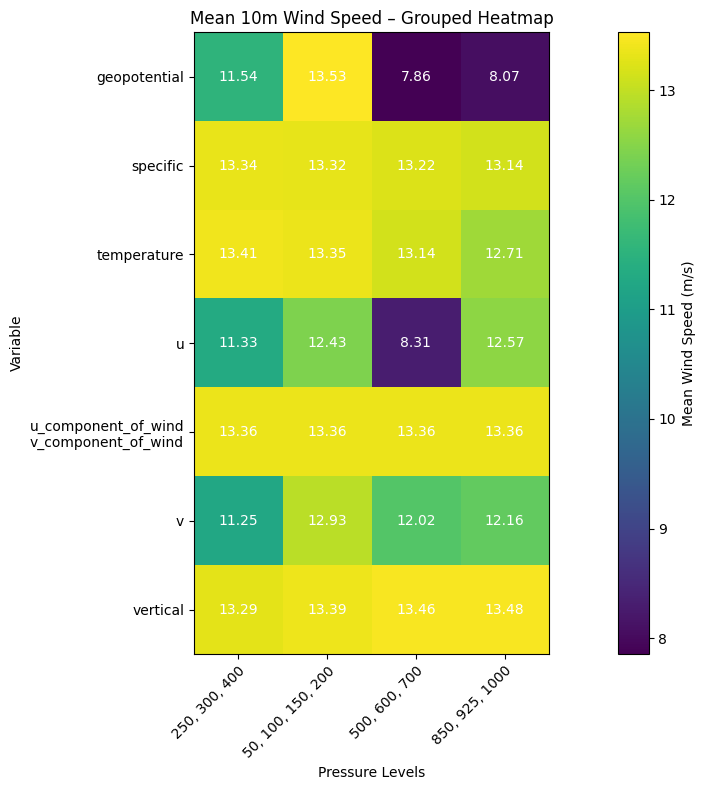

In [3]:
plot_feature_grouped_heatmap(
    masked_folder="../data/feature_occlusion/pressure_level_groups_atmospheric_variables",
    input_path="../data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc"
)


/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_52068/706595397.py:82: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fname))
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_52068/706595397.py:83: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ds = ds.isel(time=0) if "time" in ds.dims and ds.dims["time"] == 1 else ds.isel(time=time_sel)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_52068/706595397.py:82: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to Tru

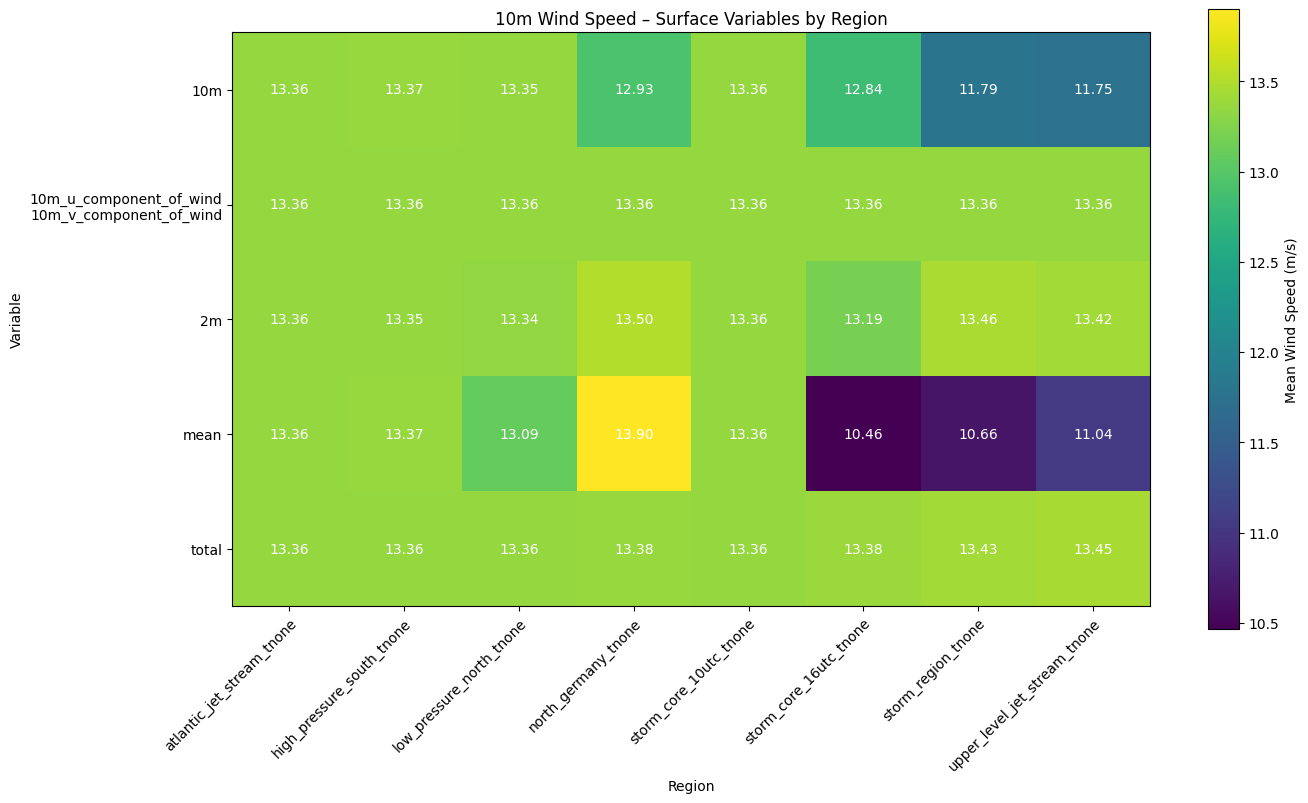

In [5]:
plot_feature_grouped_heatmap(
    masked_folder="../data/feature_occlusion/regions_surface_variables",
    input_path="../data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc",
    group_x="Region",
    title="10m Wind Speed – Surface Variables by Region"
)


/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_51806/3008095457.py:92: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fname))
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_51806/3008095457.py:93: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ds = ds.isel(time=0) if "time" in ds.dims and ds.dims["time"] == 1 else ds.isel(time=time_sel)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_51806/3008095457.py:92: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to 

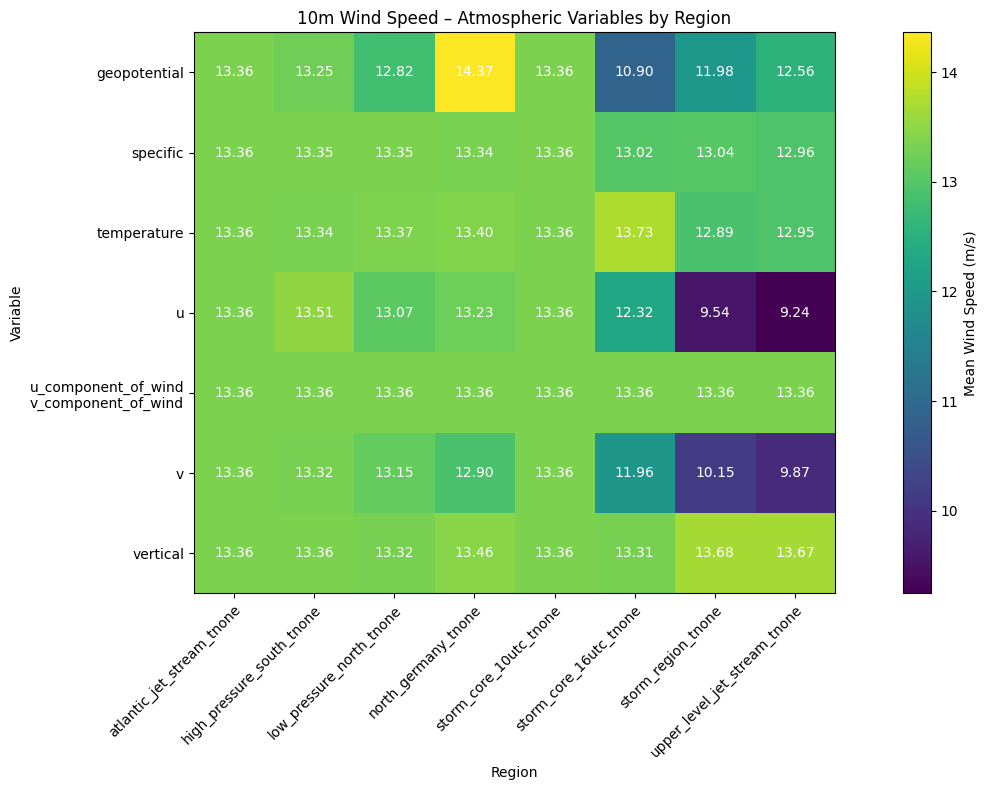

In [27]:
plot_feature_grouped_heatmap(
    masked_folder="../data/feature_occlusion/regions_atmospheric_variables",
    input_path="../data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc",
    group_x="Region",
    title="10m Wind Speed – Atmospheric Variables by Region"
)
